### Librerias

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
!pip install python-chess
!apt-get install -y stockfish
import chess
import chess.engine
engine = chess.engine.SimpleEngine.popen_uci("/usr/games/stockfish")
import logging
logging.getLogger("chess.engine").setLevel(logging.CRITICAL)

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
stockfish is already the newest version (14.1-1).
0 upgraded, 0 newly installed, 0 to remove and 42 not upgraded.


### Archivos

In [5]:
from google.colab import files
uploaded = files.upload()

Saving dataset.csv to dataset.csv


# Preprocesamiento


In [3]:
def fen_to_tensor(fen: str):
    # Tensor con las piezas y el tablero de ajedrez
    parts = fen.split()
    tensor = np.zeros((8, 8, 13), dtype=np.float32)

    board = parts[0]
    turn = parts[1]

    # Identificador de las piezas
    PIECES = {
        'P':0,'N':1,'B':2,'R':3,'Q':4,'K':5,
        'p':6,'n':7,'b':8,'r':9,'q':10,'k':11
    }

    for row_idx, row in enumerate(board.split('/')):
        col = 0
        for ch in row:
            if ch.isdigit():
                col += int(ch)
            else:
                tensor[row_idx, col, PIECES[ch]] = 1.0
                col += 1

    if turn == 'w':
        tensor[:, :, 12] = 1.0
    else:
        tensor[:, :, 12] = 0.0

    return tensor  # (8, 8, 13)

# Modelo


In [4]:
def build_chess_cnn(num_classes=4096): # 64 de origen x 64 de destino
    # Input del tensor 8x8x13
    board_input = keras.Input(shape=(8, 8, 13), name="board")

    '''
    Conv2D: detecta patrones, primero unos simples, luego más abstractos
    BatchNormalization: normaliza los valores de las convoluciones
    LeakyReLU: introduce no linealidad, deja pasar valores negativos
    kernel_size: mira los vecinos que tiene (3x3, 5x5, etc.)
    '''
    x = layers.Conv2D(64, kernel_size=3, padding="same")(board_input)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)

    x = layers.Conv2D(128, kernel_size=3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)

    x = layers.Conv2D(128, kernel_size=3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)

    x = layers.Conv2D(128, kernel_size=3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)

    # Colapsa el tablero entero, para cada canal calcula el promedio
    x = layers.GlobalAveragePooling2D()(x)

    '''
    Dense: mezcla toda la información en 256 neuronas
    Dropout: apaga el 30% de las neuronas aleatoriamente
    Softmax: convierte cada movimiento posible en probabilidades
    '''
    x = layers.Dense(256)(x)
    x = layers.LeakyReLU()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(num_classes, activation="softmax", name="move")(x)

    # Construcción del modelo
    model = keras.Model(
        inputs={"board": board_input},
        outputs=x
    )
    return model


model = build_chess_cnn()
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ board (InputLayer)              │ (None, 8, 8, 13)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 8, 8, 64)       │         7,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ move (Dense)                    │ (None, 4096)           │     1,052,672 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,464,064 (5.58 MB)

 Trainable params: 1,463,168 (5.58 MB)

 Non-trainable params: 896 (3.50 KB)

# Carga de datos

In [5]:
# Obtiene el indice de una casilla
def square_to_index(square: str) -> int:
    col = ord(square[0]) - ord('a')
    row = int(square[1]) - 1
    return row * 8 + col

# Obtiene el indice de un movimiento
def move_to_index(move_str: str) -> int:
    from_idx = square_to_index(move_str[:2])
    to_idx   = square_to_index(move_str[2:4])
    return from_idx * 64 + to_idx

In [3]:
# Carga los datos y los divide en train, validation y test
def load_and_split(csv_path, val_size = 0.1, test_size = 0.1, random_state=42):
    df = pd.read_csv(csv_path)

    boards = np.stack([fen_to_tensor(f) for f in df["fen"]])
    labels = np.array([move_to_index(m) for m in df["best"]])

    # Shuffle aleatorio
    rng = np.random.default_rng(random_state)
    indices = rng.permutation(len(boards))
    boards = boards[indices]
    labels = labels[indices]

    # Calcular cortes
    n = len(boards)
    n_test = int(n * test_size)
    n_val  = int(n * val_size)

    boards_test,  labels_test  = boards[:n_test], labels[:n_test]
    boards_val,   labels_val   = boards[n_test:n_test+n_val], labels[n_test:n_test+n_val]
    boards_train, labels_train = boards[n_test+n_val:], labels[n_test+n_val:]

    print(f"Train:      {len(boards_train):>6} posiciones")
    print(f"Validation: {len(boards_val):>6} posiciones")
    print(f"Test:       {len(boards_test):>6} posiciones")

    return (
        ({"board": boards_train}, labels_train),
        ({"board": boards_val},   labels_val),
        ({"board": boards_test},  labels_test)
    )

train_data, val_data, test_data = load_and_split("dataset.csv")

Train:      687062 posiciones
Validation:  85882 posiciones
Test:        85882 posiciones


# Ejecución del modelo

In [9]:
'''
Compilar
    - Optimizer: ajusta los pesos del modelo, Adam es el estándar
    - Loss: mide que tan equivocado está el modelo, le dice al modelo cuando
            castigar cada predicción incorrecta
    - Metrics: accuracy son las veces que el modelo predice correctamente,
            top5 son las veces que el movimiento correcto estaba en el top 5
'''
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy", # clasificación multiclase
    metrics=["accuracy", keras.metrics.SparseTopKCategoricalAccuracy(k=5, name="top5")]
)

'''
Callbacks
    - EarlyStopping: monitorea el modelo para evitar que ocurra un overfitting
    - ReduceLROnPlateau: si el modelo no mejora divide los pasos a la mitad
    - ModelCheckpoint: guarda el modelo cada vez que mejora
'''
callbacks = [
    keras.callbacks.EarlyStopping(patience=7, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=4, verbose=1),
    keras.callbacks.ModelCheckpoint("best_model.keras", save_best_only=True)
]

# Entrenar
history = model.fit(
    *train_data,
    validation_data=val_data,
    epochs=200,
    batch_size=128,
    callbacks=callbacks
)

# Descarga el entrenamiento
from google.colab import files
files.download("best_model.keras")

Epoch 1/200
5368/5368 ━━━━━━━━━━━━━━━━━━━━ 61s 10ms/step - accuracy: 0.1015 - loss: 5.3785 - top5: 0.2369 - val_accuracy: 0.1824 - val_loss: 4.5242 - val_top5: 0.3688 - learning_rate: 0.0010
Epoch 2/200
5368/5368 ━━━━━━━━━━━━━━━━━━━━ 40s 8ms/step - accuracy: 0.2257 - loss: 4.1468 - top5: 0.4280 - val_accuracy: 0.2699 - val_loss: 3.7857 - val_top5: 0.4839 - learning_rate: 0.0010
Epoch 3/200
5368/5368 ━━━━━━━━━━━━━━━━━━━━ 40s 8ms/step - accuracy: 0.2891 - loss: 3.6059 - top5: 0.5095 - val_accuracy: 0.3142 - val_loss: 3.4429 - val_top5: 0.5351 - learning_rate: 0.0010
Epoch 4/200
5368/5368 ━━━━━━━━━━━━━━━━━━━━ 40s 8ms/step - accuracy: 0.3307 - loss: 3.2717 - top5: 0.5601 - val_accuracy: 0.3515 - val_loss: 3.1550 - val_top5: 0.5764 - learning_rate: 0.0010
Epoch 5/200
5368/5368 ━━━━━━━━━━━━━━━━━━━━ 41s 8ms/step - accuracy: 0.3602 - loss: 3.0442 - top5: 0.5958 - val_accuracy: 0.3683 - val_loss: 3.0188 - val_top5: 0.5993 - learning_rate: 0.0010
Epoch 6/200
5368/5368 ━━━━━━━━━━━━━━━━━━━━ 41s 8m

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

mejor epoch: 58
val_loss:     2.0054266452789307
val_accuracy: 0.5330802798271179
val_top5:     0.769928514957428


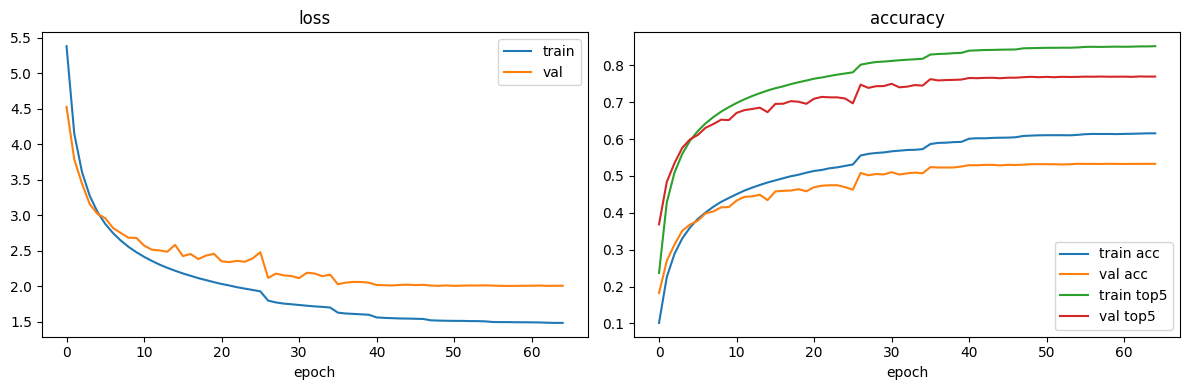

In [10]:
# Ver en qué epoch fue el mejor
print("mejor epoch:", np.argmin(history.history['val_loss']) + 1)

# Ver las métricas finales
print("val_loss:    ", min(history.history['val_loss']))
print("val_accuracy:", max(history.history['val_accuracy']))
print("val_top5:    ", max(history.history['val_top5']))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['loss'],     label='train')
ax1.plot(history.history['val_loss'], label='val')
ax1.set_title('loss')
ax1.set_xlabel('epoch')
ax1.legend()

ax2.plot(history.history['accuracy'],     label='train acc')
ax2.plot(history.history['val_accuracy'], label='val acc')
ax2.plot(history.history['top5'],         label='train top5')
ax2.plot(history.history['val_top5'],     label='val top5')
ax2.set_title('accuracy')
ax2.set_xlabel('epoch')
ax2.legend()

plt.tight_layout()
plt.show()

  Engine reiniciado en posición 50/500
  Engine reiniciado en posición 100/500
  Engine reiniciado en posición 150/500
  Engine reiniciado en posición 200/500
  Engine reiniciado en posición 250/500
  Engine reiniciado en posición 300/500
  Engine reiniciado en posición 350/500
  Engine reiniciado en posición 400/500
  Engine reiniciado en posición 450/500
Movimiento exacto:    325/500 (65.0%)
Movimientos con mate: 0/500  (0.0%)
ACPL promedio:        6693.9 centipeones


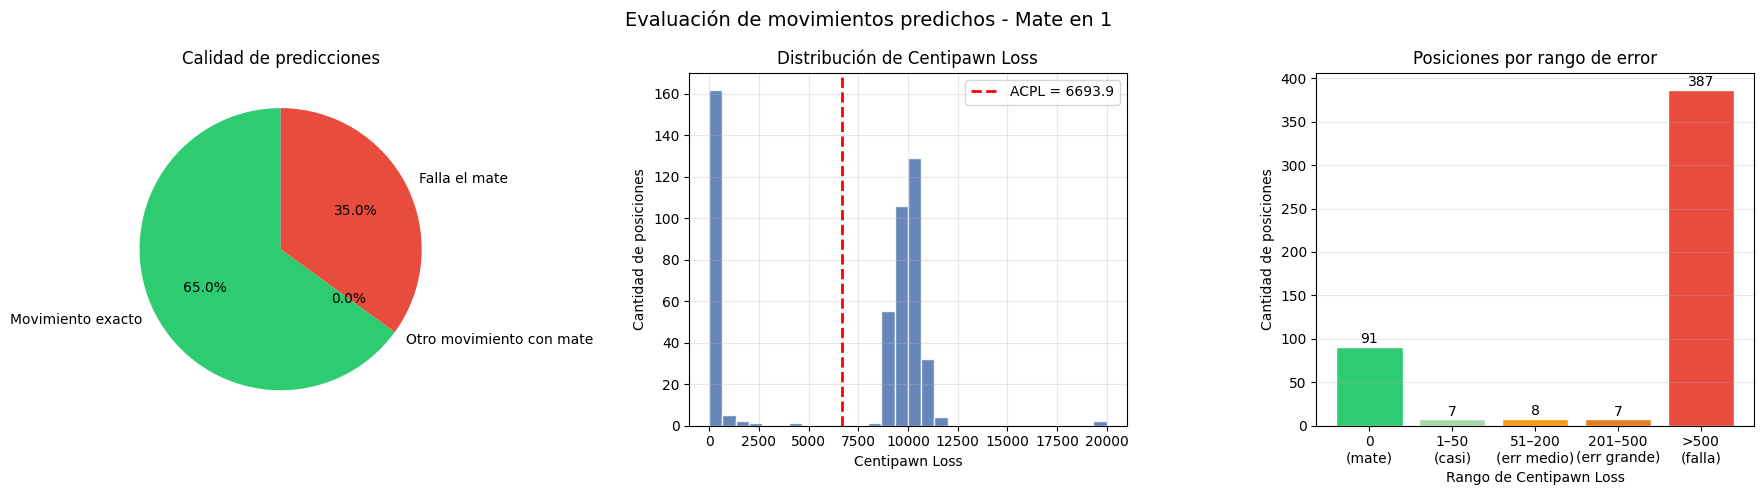

In [12]:
def es_mate_en_1(fen, movimiento):
    board = chess.Board(fen)
    move  = chess.Move.from_uci(movimiento)
    if move in board.legal_moves:
        board.push(move)
        return board.is_checkmate()
    return False

def evaluar_posicion(board, tiempo=0.05):
    try:
        result = engine.analyse(board, chess.engine.Limit(time=tiempo))
        score  = result["score"].pov(board.turn)  # siempre desde el turno actual
        if score.is_mate():
            return 10000 * (1 if score.mate() > 0 else -1)
        return score.score()
    except Exception:
        return 0

def centipawn_loss(fen, movimiento_jugado):
    board = chess.Board(fen)
    turno = board.turn  # guardamos el turno antes de mover

    eval_antes = evaluar_posicion(board)

    try:
        move = chess.Move.from_uci(movimiento_jugado)
        if move not in board.legal_moves:
            return 500  # movimiento ilegal
        board.push(move)
    except Exception:
        return 500

    # Evaluamos desde el punto de vista del oponente y negamos
    eval_despues_oponente = evaluar_posicion(board)
    eval_despues = -eval_despues_oponente  # convertir al punto de vista original

    loss = eval_antes - eval_despues
    return max(0, loss)

def evaluar_y_graficar(model, df_test, n_muestras=500):
    n = min(n_muestras, len(df_test))
    muestra = df_test.sample(n, random_state=42).reset_index(drop=True)

    resultados = []
    engine = None

    def abrir_engine():
        return chess.engine.SimpleEngine.popen_uci("/usr/games/stockfish")

    engine = abrir_engine()

    for i, (_, row) in enumerate(muestra.iterrows()):
        # Reinicia el engine cada 50 posiciones
        if i > 0 and i % 50 == 0:
            try:
                engine.quit()
            except:
                pass
            engine = abrir_engine()
            print(f"  Engine reiniciado en posición {i}/{n}")

        fen  = row["fen"]
        best = row["best"]

        tensor = fen_to_tensor(fen)[np.newaxis]
        pred   = model.predict({"board": tensor}, verbose=0)[0]
        idx    = np.argmax(pred)

        from_sq  = idx // 64
        to_sq    = idx % 64
        mov_pred = chess.square_name(from_sq) + chess.square_name(to_sq)

        es_correcto = (mov_pred == best)
        da_mate     = es_mate_en_1(fen, mov_pred)

        # Centipawn loss con manejo de error
        try:
            board = chess.Board(fen)

            # Evaluación antes
            result     = engine.analyse(board, chess.engine.Limit(time=0.05))
            score      = result["score"].pov(board.turn)  # <-- cambio aquí
            eval_antes = 10000 * (1 if score.mate() > 0 else -1) if score.is_mate() else score.score()

            move = chess.Move.from_uci(mov_pred)
            if move not in board.legal_moves:
                raise ValueError("movimiento ilegal")
            board.push(move)

            # Evaluación después (negada porque ahora es turno del oponente)
            result          = engine.analyse(board, chess.engine.Limit(time=0.05))
            score           = result["score"].pov(board.turn)
            eval_despues    = -(10000 * (1 if score.mate() > 0 else -1) if score.is_mate() else score.score())

            loss = max(0, eval_antes - eval_despues)
        except Exception:
            loss = 0 if da_mate else 500

        resultados.append({
            "correcto": es_correcto,
            "da_mate":  da_mate,
            "loss":     loss,
        })

    try:
        engine.quit()
    except:
        pass

    # Métricas y gráficas igual que antes
    correctos = sum(r["correcto"] for r in resultados)
    dan_mate  = sum(r["da_mate"]  for r in resultados)
    losses    = [r["loss"]        for r in resultados]
    acpl      = np.mean(losses)

    print(f"Movimiento exacto:    {correctos}/{n} ({correctos/n:.1%})")
    print(f"Movimientos con mate: {dan_mate}/{n}  ({dan_mate/n:.1%})")
    print(f"ACPL promedio:        {acpl:.1f} centipeones")

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle("Evaluación de movimientos predichos - Mate en 1", fontsize=14)

    solo_mate  = max(0, dan_mate - correctos)
    falla_mate = n - correctos - solo_mate

    axes[0].pie(
        [correctos, solo_mate, falla_mate],
        labels=["Movimiento exacto", "Otro movimiento con mate", "Falla el mate"],
        colors=["#2ecc71", "#f39c12", "#e74c3c"],
        autopct="%1.1f%%", startangle=90
    )
    axes[0].set_title("Calidad de predicciones")

    axes[1].hist(losses, bins=30, color="#4C72B0", edgecolor="white", alpha=0.85)
    axes[1].axvline(acpl, color="red", linestyle="--", linewidth=2, label=f"ACPL = {acpl:.1f}")
    axes[1].set_title("Distribución de Centipawn Loss")
    axes[1].set_xlabel("Centipawn Loss")
    axes[1].set_ylabel("Cantidad de posiciones")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    rangos    = [0, 1, 50, 200, 500, float("inf")]
    etiquetas = ["0\n(mate)", "1–50\n(casi)",
                 "51–200\n(err medio)", "201–500\n(err grande)", ">500\n(falla)"]
    colores   = ["#2ecc71", "#a8d8a8", "#f39c12", "#e67e22", "#e74c3c"]
    conteos   = [sum(rangos[i] <= l < rangos[i+1] for l in losses) for i in range(len(etiquetas))]

    bars = axes[2].bar(etiquetas, conteos, color=colores, edgecolor="white")
    axes[2].set_title("Posiciones por rango de error")
    axes[2].set_xlabel("Rango de Centipawn Loss")
    axes[2].set_ylabel("Cantidad de posiciones")
    axes[2].grid(True, alpha=0.3, axis="y")
    for bar, conteo in zip(bars, conteos):
        axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                     str(conteo), ha="center", va="bottom", fontsize=10)

    plt.tight_layout()
    plt.savefig("evaluacion_movimientos.png", dpi=150, bbox_inches="tight")
    plt.show()

model = keras.models.load_model("best_model.keras")
df = pd.read_csv("dataset.csv")
evaluar_y_graficar(model, df)

# Modelo mejorado

In [6]:
def make_dataset(fens, labels, batch_size=512, shuffle=False, cache_path=None):
    fens_array   = np.array(fens)
    labels_array = np.array(labels, dtype=np.int32)
    indices      = np.arange(len(fens_array))

    def generator():
        for i in indices:
            yield fen_to_tensor(fens_array[i]).astype(np.float32), labels_array[i], get_legal_mask(fens_array[i])

    dataset = tf.data.Dataset.from_generator(
        generator,
        output_signature=(
            tf.TensorSpec(shape=(8, 8, 13), dtype=tf.float32),
            tf.TensorSpec(shape=(),         dtype=tf.int32),
            tf.TensorSpec(shape=(4096,),    dtype=tf.float32),
        )
    )

    # Primera época: calcula y guarda en disco
    # Épocas siguientes: lee directo del disco sin recalcular
    if cache_path:
        dataset = dataset.cache(cache_path)

    if shuffle:
        dataset = dataset.shuffle(buffer_size=10000)

    return dataset.repeat().batch(batch_size).prefetch(tf.data.AUTOTUNE)

In [7]:
def load_and_split_with_fen(csv_path, val_size=0.1, test_size=0.1, random_state=42):
    df = pd.read_csv(csv_path)

    fens   = df["fen"].values
    labels = np.array([move_to_index(m) for m in df["best"]])

    rng     = np.random.default_rng(random_state)
    indices = rng.permutation(len(fens))
    fens, labels = fens[indices], labels[indices]

    n      = len(fens)
    n_test = int(n * test_size)
    n_val  = int(n * val_size)

    fens_test,  fens_val,  fens_train  = fens[:n_test],   fens[n_test:n_test+n_val],   fens[n_test+n_val:]
    labels_test, labels_val, labels_train = labels[:n_test], labels[n_test:n_test+n_val], labels[n_test+n_val:]

    print(f"Train:      {len(fens_train):>6} posiciones")
    print(f"Validation: {len(fens_val):>6} posiciones")
    print(f"Test:       {len(fens_test):>6} posiciones")

    return (fens_train, labels_train), (fens_val, labels_val), (fens_test, labels_test)

train_data, val_data, test_data = load_and_split_with_fen("dataset.csv")

Train:      687062 posiciones
Validation:  85882 posiciones
Test:        85882 posiciones


In [8]:
# Obtiene todos los movimientos posibles en un tablero
def get_legal_mask(fen: str) -> np.ndarray:
    board = chess.Board(fen)
    mask  = np.zeros(4096, dtype=np.float32)
    for move in board.legal_moves:
        mask[move.from_square * 64 + move.to_square] = 1.0
    return mask

class ChessCNNWithLegalLoss(keras.Model):
    def __init__(self, base_model, penalty_weight=2.0):
        super().__init__()
        self.base_model     = base_model
        self.penalty_weight = penalty_weight

        # Para que los callbacks de accuracy sigan funcionando
        self.loss_tracker = keras.metrics.Mean(name="loss")
        self.acc_tracker = keras.metrics.SparseCategoricalAccuracy(name="accuracy")
        self.top5_tracker = keras.metrics.SparseTopKCategoricalAccuracy(k=5, name="top5")
        self.illegal_tracker = keras.metrics.Mean(name="illegal_prob") # movimientos ilegales

    # para que ModelCheckpoint funcione
    def get_config(self):
        config = super().get_config()
        config.update({"penalty_weight": self.penalty_weight})
        return config

    @property
    def metrics(self):
        return [self.loss_tracker, self.acc_tracker, self.top5_tracker, self.illegal_tracker]

    # para el batch por el CNN
    def _compute_loss(self, inputs, labels, masks, training):
        probs = self.base_model({"board": inputs}, training=training)

        # masks ya llega como tensor float32 — sin strings, sin py_function
        ce           = keras.losses.sparse_categorical_crossentropy(labels, probs)
        illegal_prob = tf.reduce_sum(probs * (1.0 - masks), axis=-1)
            # mide que tan lejos está del movimiento correcto

        return probs, ce + self.penalty_weight * illegal_prob, illegal_prob

    # se llama una vez por batch
    def train_step(self, data):
        inputs, labels, masks = data

        # graba las operaciones matemáticas para el aprendizaje
        with tf.GradientTape() as tape:
            probs, loss, illegal_prob = self._compute_loss(inputs, labels, masks, training=True)

        # calcula cuanto contribuyo cada peso y que tanto reduce la perdida
        grads = tape.gradient(loss, self.base_model.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.base_model.trainable_variables))

        # actualiza los contadores
        self.loss_tracker.update_state(loss)
        self.acc_tracker.update_state(labels, probs)
        self.top5_tracker.update_state(labels, probs)
        self.illegal_tracker.update_state(illegal_prob)
        return {m.name: m.result() for m in self.metrics}

    # solo calcula las metricas, no los pesos
    def test_step(self, data):
        inputs, labels, masks = data
        probs, loss, illegal_prob = self._compute_loss(inputs, labels, masks, training=False)

        self.loss_tracker.update_state(loss)
        self.acc_tracker.update_state(labels, probs)
        self.top5_tracker.update_state(labels, probs)
        self.illegal_tracker.update_state(illegal_prob)
        return {m.name: m.result() for m in self.metrics}

In [ ]:
base_model = build_chess_cnn()
model = ChessCNNWithLegalLoss(base_model, penalty_weight = 2.0)

model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3))

callbacks = [
    keras.callbacks.EarlyStopping(patience=7, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=4, verbose=1),
    keras.callbacks.ModelCheckpoint("upgraded_model.keras", save_best_only=True)
]

(fens_train, labels_train) = train_data
(fens_val,   labels_val)   = val_data

train_ds = make_dataset(fens_train, labels_train, batch_size=512, shuffle=True,  cache_path="/content/cache_train")
val_ds   = make_dataset(fens_val,   labels_val,   batch_size=512, shuffle=False, cache_path="/content/cache_val")

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=200,
    callbacks=callbacks
)
files.download("upgraded_model.keras")

Epoch 1/200
  48573/Unknown 2396s 49ms/step - accuracy: 0.3330 - illegal_prob: 0.4383 - loss: 4.2854 - top5: 0.5459

# Interfaz gráfica

In [13]:
from IPython.display import HTML, display

chess_editor_html = """
<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<style>
  :root {
    --light:#f0d9b5; --dark:#b58863; --border:#8a6642;
    --bg:#1a1a2e; --panel:#16213e; --accent:#e2b714;
    --green:#6aaa64; --text:#e8e0d0; --sub:#9a8f82;
    --sq:64px;
  }
  #ce-root *{box-sizing:border-box;margin:0;padding:0;font-family:monospace;}
  #ce-root{
    background:var(--bg);padding:20px;border-radius:12px;
    display:flex;gap:20px;flex-wrap:wrap;
    align-items:flex-start;justify-content:center;color:var(--text);
  }
  #ce-root h1{
    width:100%;text-align:center;font-size:1.3rem;
    color:var(--accent);letter-spacing:.06em;margin-bottom:4px;
    font-family:Georgia,serif;
  }
  .bwrap{display:flex;flex-direction:column;align-items:center;}
  .file-row{display:flex;height:16px;padding-left:20px;}
  .file-row span{width:var(--sq);text-align:center;font-size:10px;color:var(--sub);}
  .rank-col{display:flex;flex-direction:column;width:20px;}
  .rank-col span{height:var(--sq);display:flex;align-items:center;justify-content:center;font-size:10px;color:var(--sub);}
  #ce-board{
    display:grid;
    grid-template-columns:repeat(8,var(--sq));
    grid-template-rows:repeat(8,var(--sq));
    border:3px solid var(--border);
    box-shadow:0 0 40px rgba(0,0,0,.7);
    position:relative;user-select:none;
  }
  .sq{
    width:var(--sq);height:var(--sq);
    display:flex;align-items:center;justify-content:center;
    position:relative;cursor:crosshair;
  }
  .sq.light{background:var(--light);}
  .sq.dark {background:var(--dark);}
  .sq.over.light{background:rgba(246,201,14,.6);}
  .sq.over.dark {background:rgba(246,201,14,.5);}
  .sq.erasing{cursor:not-allowed;}
  .piece{
    font-size:40px;line-height:1;cursor:grab;
    position:absolute;width:var(--sq);height:var(--sq);
    display:flex;align-items:center;justify-content:center;
    z-index:2;pointer-events:auto;
  }
  /* Piezas blancas */
  .piece.white-piece{
    color:#ffffff;
    filter: drop-shadow(0 2px 4px rgba(0,0,0,.5));
  }
  .piece.white-piece:hover{
    filter:drop-shadow(0 4px 10px rgba(0,0,0,.8)) brightness(1.05);
  }
  /* Piezas negras */
  .piece.black-piece{
    color:#1a1a1a;
    filter: drop-shadow(0 1px 2px rgba(255,255,255,.4)) drop-shadow(0 2px 4px rgba(0,0,0,.6));
  }
  .piece.black-piece:hover{
    filter:drop-shadow(0 1px 3px rgba(255,255,255,.5)) drop-shadow(0 4px 10px rgba(0,0,0,.8));
  }
  .panel{
    background:var(--panel);border:1px solid #2a2a4a;
    border-radius:10px;padding:16px;width:230px;
    display:flex;flex-direction:column;gap:14px;
    box-shadow:0 8px 32px rgba(0,0,0,.4);
  }
  .panel h2{font-size:.85rem;color:var(--accent);border-bottom:1px solid #2a2a4a;padding-bottom:8px;font-family:Georgia,serif;}
  .lbl{font-size:9px;color:var(--sub);text-transform:uppercase;letter-spacing:.1em;margin-bottom:4px;}
  .palette{display:flex;flex-direction:column;gap:6px;}
  .pal-row{display:flex;gap:5px;}
  .pal-btn{
    width:44px;height:44px;font-size:26px;
    background:#0d0d1a;border:2px solid #2a2a4a;
    border-radius:6px;cursor:pointer;display:flex;
    align-items:center;justify-content:center;
    transition:all .15s;
    position:relative;
  }
  /* color de piezas en la paleta */
  .pal-btn.white-pal { color: #ffffff; text-shadow: 0 1px 3px rgba(0,0,0,.8); }
  .pal-btn.black-pal { color: #1a1a1a; text-shadow: 0 0 3px rgba(255,255,255,.5); }
  .pal-btn:hover{border-color:var(--accent);transform:scale(1.08);}
  .pal-btn.active{border-color:var(--accent);background:#1e2a1e;box-shadow:0 0 8px rgba(226,183,20,.4);}
  .pal-btn.eraser{font-size:16px;color:#e05c5c;}
  .pal-btn.eraser.active{border-color:#e05c5c;background:#2a1010;box-shadow:0 0 8px rgba(224,92,92,.4);}
  .fen-box{
    background:#0d0d1a;border:1px solid #2a2a4a;border-radius:6px;
    padding:8px 10px;font-size:10px;color:var(--green);
    word-break:break-all;line-height:1.6;min-height:48px;
  }
  .btn{
    background:none;border:1px solid #3a3a5a;color:var(--text);
    font-size:11px;padding:7px 10px;border-radius:5px;
    cursor:pointer;transition:all .15s;font-family:monospace;
  }
  .btn:hover{border-color:var(--accent);color:var(--accent);}
  .btn.danger{border-color:#e05c5c;color:#e05c5c;}
  .btn-row{display:flex;gap:6px;flex-wrap:wrap;}
  .turn-sel{display:flex;gap:6px;}
  .turn-opt{
    flex:1;padding:6px;text-align:center;font-size:11px;
    border:1px solid #3a3a5a;border-radius:5px;cursor:pointer;
    transition:all .15s;
  }
  .turn-opt:hover{border-color:var(--accent);}
  .turn-opt.active{border-color:var(--accent);background:rgba(226,183,20,.12);color:var(--accent);}
  .status{font-size:10px;color:var(--sub);min-height:14px;}
  .fen-input{
    background:#0d0d1a;border:1px solid #2a2a4a;border-radius:5px;
    color:var(--green);font-family:monospace;font-size:10px;
    padding:6px 8px;width:100%;outline:none;
  }
  .fen-input:focus{border-color:var(--accent);}
</style>
</head>
<body>
<div id="ce-root">
  <h1>♟ Position Editor</h1>

  <div class="bwrap">
    <div class="file-row" id="ce-files"></div>
    <div style="display:flex">
      <div class="rank-col" id="ce-ranks"></div>
      <div id="ce-board"></div>
    </div>
  </div>

  <div class="panel">
    <h2>Piece Palette</h2>
    <div class="palette">
      <div class="lbl">White</div>
      <div class="pal-row" id="pal-white"></div>
      <div class="lbl" style="margin-top:4px">Black</div>
      <div class="pal-row" id="pal-black"></div>
      <div class="pal-row" style="margin-top:4px">
        <div class="pal-btn eraser" id="pal-eraser" title="Erase piece">✕</div>
      </div>
    </div>

    <div class="lbl" style="margin-top:4px">Active turn</div>
    <div class="turn-sel">
      <div class="turn-opt active" id="turn-w" onclick="setTurn('w')">♔ White</div>
      <div class="turn-opt"        id="turn-b" onclick="setTurn('b')">♚ Black</div>
    </div>

    <div>
      <div class="lbl">FEN output</div>
      <div class="fen-box" id="ce-fen"></div>
      <button class="btn" style="width:100%;margin-top:6px" onclick="ceCopyFen()">Copy FEN</button>
    </div>

    <div>
      <div class="lbl">Load FEN</div>
      <input class="fen-input" id="ce-fen-in" placeholder="Paste FEN here..." />
      <button class="btn" style="width:100%;margin-top:6px" onclick="ceLoadFen()">Load</button>
    </div>

    <div class="status" id="ce-status">Select a piece, then click a square</div>

    <div class="btn-row">
      <button class="btn" onclick="ceUndo()">⟵ Undo</button>
      <button class="btn" onclick="ceFlip()">⇅ Flip</button>
    </div>
    <div class="btn-row">
      <button class="btn" onclick="ceReset()">Start pos</button>
      <button class="btn danger" onclick="ceClear()">Clear</button>
    </div>
  </div>
</div>

<script>
(function(){
  const GLYPHS={K:'♔',Q:'♕',R:'♖',B:'♗',N:'♘',P:'♙',k:'♚',q:'♛',r:'♜',b:'♝',n:'♞',p:'♟'};
  const WHITE_PIECES=['K','Q','R','B','N','P'];
  const BLACK_PIECES=['k','q','r','b','n','p'];
  const START=[
    ['r','n','b','q','k','b','n','r'],
    ['p','p','p','p','p','p','p','p'],
    [,,,,,,,,],[,,,,,,,,],[,,,,,,,,],[,,,,,,,,],
    ['P','P','P','P','P','P','P','P'],
    ['R','N','B','Q','K','B','N','R'],
  ].map(r=>Array.from({length:8},(_,i)=>r[i]||null));

  let grid, flipped=false, turn='w';
  let selected=null;
  let dragFrom=null, clone=null;
  let history=[];
  const files=['a','b','c','d','e','f','g','h'];
  const cp=g=>g.map(r=>[...r]);

  function isBlack(p){ return p === p.toLowerCase(); }

  function toFen(){
    let f='';
    for(let r=0;r<8;r++){
      let e=0;
      for(let c=0;c<8;c++){const p=grid[r][c];if(!p){e++;}else{if(e){f+=e;e=0;}f+=p;}}
      if(e)f+=e;if(r<7)f+='/';
    }
    return f+' '+turn+' - - 0 1';
  }

  function parseFen(fen){
    const parts=fen.trim().split(' ');
    const rows=parts[0].split('/');
    if(rows.length!==8)throw new Error('Invalid FEN');
    const g=[];
    for(const row of rows){
      const r=[];
      for(const ch of row){
        if('12345678'.includes(ch))for(let i=0;i<+ch;i++)r.push(null);
        else if('KQRBNPkqrbnp'.includes(ch))r.push(ch);
        else throw new Error('Invalid piece: '+ch);
      }
      if(r.length!==8)throw new Error('Row length error');
      g.push(r);
    }
    return{grid:g,turn:parts[1]==='b'?'b':'w'};
  }

  function buildPalette(){
    function makeBtn(key){
      const btn=document.createElement('div');
      btn.className='pal-btn ' + (isBlack(key) ? 'black-pal' : 'white-pal');
      btn.id='pal-'+key;
      btn.textContent=GLYPHS[key];
      btn.title=key;
      btn.addEventListener('mousedown',e=>{e.preventDefault();selectPalette(key);});
      return btn;
    }
    const pw=document.getElementById('pal-white');
    const pb=document.getElementById('pal-black');
    WHITE_PIECES.forEach(k=>pw.appendChild(makeBtn(k)));
    BLACK_PIECES.forEach(k=>pb.appendChild(makeBtn(k)));
    document.getElementById('pal-eraser').addEventListener('mousedown',e=>{e.preventDefault();selectPalette('X');});
  }

  function selectPalette(key){
    [...WHITE_PIECES,...BLACK_PIECES].forEach(k=>{
      const b=document.getElementById('pal-'+k);
      if(b)b.classList.remove('active');
    });
    document.getElementById('pal-eraser').classList.remove('active');
    if(selected===key){
      selected=null;
      document.getElementById('ce-status').textContent='Drag mode — drag pieces freely';
    } else {
      selected=key;
      const b=document.getElementById('pal-'+key)||document.getElementById('pal-eraser');
      if(b)b.classList.add('active');
      document.getElementById('ce-status').textContent=
        key==='X'?'Click a square to erase':'Click a square to place '+(GLYPHS[key]||'');
    }
  }

  function render(){
    const bd=document.getElementById('ce-board');
    bd.innerHTML='';
    const rl=document.getElementById('ce-ranks');
    const fl=document.getElementById('ce-files');
    rl.innerHTML='';fl.innerHTML='';
    const ranks=flipped?['1','2','3','4','5','6','7','8']:['8','7','6','5','4','3','2','1'];
    const fcols=flipped?['h','g','f','e','d','c','b','a']:['a','b','c','d','e','f','g','h'];
    ranks.forEach(r=>{const s=document.createElement('span');s.textContent=r;rl.appendChild(s);});
    fcols.forEach(f=>{const s=document.createElement('span');s.textContent=f;fl.appendChild(s);});

    for(let vr=0;vr<8;vr++){
      for(let vc=0;vc<8;vc++){
        const row=flipped?7-vr:vr, col=flipped?7-vc:vc;
        const sq=document.createElement('div');
        sq.className='sq '+((row+col)%2===0?'light':'dark');
        if(selected==='X')sq.classList.add('erasing');
        sq.dataset.r=row;sq.dataset.c=col;
        sq.addEventListener('mousedown',onSqDown);
        sq.addEventListener('mouseenter',onSqEnter);
        sq.addEventListener('mouseleave',onSqLeave);
        bd.appendChild(sq);
        const p=grid[row][col];
        if(p){
          const pe=document.createElement('div');
          // ── color de pieza según color ──
          pe.className = 'piece ' + (isBlack(p) ? 'black-piece' : 'white-piece');
          pe.textContent=GLYPHS[p];
          pe.dataset.r=row;pe.dataset.c=col;
          pe.addEventListener('mousedown',onPcDown);
          sq.appendChild(pe);
        }
      }
    }
    document.getElementById('ce-fen').textContent=toFen();
  }

  function onSqEnter(e){if(selected)e.currentTarget.classList.add('over');}
  function onSqLeave(e){e.currentTarget.classList.remove('over');}

  function onSqDown(e){
    if(!selected)return;
    e.preventDefault();e.stopPropagation();
    const r=+e.currentTarget.dataset.r, c=+e.currentTarget.dataset.c;
    save();
    if(selected==='X'){grid[r][c]=null;}
    else{grid[r][c]=selected;}
    render();
  }

  function onPcDown(e){
    if(selected)return;
    e.preventDefault();e.stopPropagation();
    const r=+e.currentTarget.dataset.r, c=+e.currentTarget.dataset.c;
    dragFrom=[r,c];
    const pe=e.currentTarget;
    clone=pe.cloneNode(true);
    Object.assign(clone.style,{
      position:'fixed',pointerEvents:'none',zIndex:'9999',
      fontSize:'48px',width:'64px',height:'64px',
      transform:'translate(-50%,-50%) scale(1.15)',
      transition:'none',left:e.clientX+'px',top:e.clientY+'px'
    });
    document.body.appendChild(clone);
    document.addEventListener('mousemove',onMM);
    document.addEventListener('mouseup',onMU);
  }

  function onMM(e){if(clone){clone.style.left=e.clientX+'px';clone.style.top=e.clientY+'px';}}

  function onMU(e){
    document.removeEventListener('mousemove',onMM);
    document.removeEventListener('mouseup',onMU);
    if(clone){clone.remove();clone=null;}
    if(!dragFrom)return;
    const tgt=sqFromPt(e.clientX,e.clientY);
    if(tgt){
      const[tr,tc]=tgt;
      const[fr,fc]=dragFrom;
      if(fr!==tr||fc!==tc){
        save();
        grid[tr][tc]=grid[fr][fc];
        grid[fr][fc]=null;
      }
    }
    dragFrom=null;
    render();
  }

  function sqFromPt(x,y){
    const bd=document.getElementById('ce-board');
    const rc=bd.getBoundingClientRect();
    const sw=rc.width/8,sh=rc.height/8;
    const vc=Math.floor((x-rc.left)/sw),vr=Math.floor((y-rc.top)/sh);
    if(vc<0||vc>7||vr<0||vr>7)return null;
    return[flipped?7-vr:vr,flipped?7-vc:vc];
  }

  function save(){history.push({grid:cp(grid),turn});}

  window.setTurn=function(t){
    turn=t;
    document.getElementById('turn-w').classList.toggle('active',t==='w');
    document.getElementById('turn-b').classList.toggle('active',t==='b');
    document.getElementById('ce-fen').textContent=toFen();
  };

  window.ceUndo=function(){
    if(!history.length){document.getElementById('ce-status').textContent='Nothing to undo';return;}
    const s=history.pop();grid=s.grid;turn=s.turn;
    document.getElementById('turn-w').classList.toggle('active',turn==='w');
    document.getElementById('turn-b').classList.toggle('active',turn==='b');
    render();
  };

  window.ceFlip=function(){flipped=!flipped;render();};

  window.ceReset=function(){
    save();
    grid=START.map(r=>[...r]);turn='w';
    document.getElementById('turn-w').classList.add('active');
    document.getElementById('turn-b').classList.remove('active');
    render();
  };

  window.ceClear=function(){
    save();
    grid=Array.from({length:8},()=>Array(8).fill(null));
    render();
  };

  window.ceCopyFen=function(){
    navigator.clipboard&&navigator.clipboard.writeText(toFen()).then(()=>{
      const s=document.getElementById('ce-status');
      s.textContent='✓ FEN copied!';setTimeout(()=>s.textContent='',2000);
    });
  };

  window.ceLoadFen=function(){
    const val=document.getElementById('ce-fen-in').value.trim();
    try{
      const r=parseFen(val);
      save();grid=r.grid;turn=r.turn;
      document.getElementById('turn-w').classList.toggle('active',turn==='w');
      document.getElementById('turn-b').classList.toggle('active',turn==='b');
      document.getElementById('ce-fen-in').value='';
      document.getElementById('ce-status').textContent='✓ FEN loaded';
      render();
    }catch(err){
      document.getElementById('ce-status').textContent='❌ Invalid FEN: '+err.message;
    }
  };

  buildPalette();
  grid=START.map(r=>[...r]);
  render();
})();
</script>
</body>
</html>
"""

display(HTML(chess_editor_html))


In [14]:
def index_to_square(idx: int) -> str:
    col = idx % 8
    row = idx // 8
    return chr(ord('a') + col) + str(row + 1)

def index_to_move(idx: int) -> str:
    from_idx = idx // 64
    to_idx   = idx % 64
    return index_to_square(from_idx) + index_to_square(to_idx)

def predict_top5(fen: str, model) -> None:
    board = fen_to_tensor(fen)[np.newaxis]  # (1, 8, 8, 13)
    probs = model.predict({"board": board}, verbose=0)[0]  # (4096,)

    top5_idx = np.argsort(probs)[::-1][:5]

    print(f"FEN: {fen}")
    print(f"Turno: {'blancas' if fen.split()[1] == 'w' else 'negras'}")
    for i, idx in enumerate(top5_idx):
        movimiento = index_to_move(idx)
        probabilidad = probs[idx] * 100
        print(f"  {i+1}. {movimiento}   ({probabilidad:.1f}%)")


# Usar
model = tf.keras.models.load_model("best_model.keras")
# model = tf.keras.models.load_model("upgraded_model.keras")
fen = "kn6/pp6/8/1N6/8/5K2/8/8 w - - 0 1"
predict_top5(fen, model)

FEN: kn6/pp6/8/1N6/8/5K2/8/8 w - - 0 1
Turno: blancas
  1. f3e4   (33.7%)
  2. f3f4   (29.3%)
  3. f3g4   (28.2%)
  4. f3g2   (1.7%)
  5. b5c7   (1.6%)
